# Install Triton and verify installation

In [1]:
# Select GPU T4 x 2 accelator and install triton
!pip install triton

In [2]:
# Verify installation
import torch
import triton
import triton.language as tl 

# Check if Triton can access the GPU
print(f"Triton version: {triton.__version__}")
print(f"GPU Available: {torch.cuda.is_available()}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")

# Simple test: define a JIT kernel
@triton.jit
def dummy_kernel(x_ptr):
    return

print("Triton JIT check: Success")

Triton version: 3.5.0
GPU Available: True
GPU Name: Tesla T4
Triton JIT check: Success


In [3]:
# Set cache directory
import os
os.environ["TRITON_CACHE_DIR"] = "/kaggle/working/triton_cache"

# Set device
current_device_id = torch.cuda.current_device()
DEVICE = torch.device(f"cuda:{current_device_id}")

# Matrix Multiplication

### Concepts
- Block-level matrix multiplications
- Multi-dimensional pointer arithmetic
- PID reordering for improved SRAM sharing b/w PIDs
- Automatic performance tuning

#### Inputs
- $A \in \mathbb{R}^{m \times k}$
- $B \in \mathbb{R}^{k \times n}$
#### Output
- $C \in \mathbb{R}^{m \times n}$
#### Algorithm
```python
# Do in parallel
for m in range(0, M, BLOCK_SIZE_M):
    # Do in parallel
    for n in range(0, N, BLOCK_SIZE_N):
        accumulate = zeros((BLOCK_SIZE_M, BLOCK_SIZE_N))
        for k in range(0, K, BLOCK_SIZE_K):
            a = A[m : m + BLOCK_SIZE_M, k : k + BLOCK_SIZE_N]
            b = B[k : k + BLOCK_SIZE_K, n : n + BLOCK_SIZE_N]
            accumulate += dot(a, b)
        C[m : m + BLOCK_SIZE_M, n : n + BLOCK_SIZE_N] = accumulate
```

In [4]:
# Example
A = torch.randint(1, 10, (3, 4))
B = torch.randint(-10, -1, (4, 2))
C = torch.matmul(A, B)
print("C:\n", C, end="\n\n")

# Naive implementation
D = torch.zeros((3, 2)).type_as(A)
for i in range(A.shape[0]):
    for j in range(B.shape[1]):
        total = 0
        for k in range(A.shape[1]):
            total += A[i, k] * B[k, j]
        D[i, j] = total

print("D:\n", D)

C:
 tensor([[-196, -131],
        [-113,  -82],
        [-178, -127]])

D:
 tensor([[-196, -131],
        [-113,  -82],
        [-178, -127]])


### Automatic Tuning
Define several meta-parameter configurations for Triton to benchmark and automatically select from later based on which one performs best on Kaggle’s T4 GPU

In [5]:
autotune_configs = [
    triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 64, 'GROUP_SIZE_M': 8}, num_stages=3, num_warps=8),
    triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4, num_warps=4),
    triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4, num_warps=4),
    triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4, num_warps=4),
    triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4, num_warps=4),
    triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 32, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4, num_warps=4),
    triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 32, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=5, num_warps=2),
    triton.Config({'BLOCK_SIZE_M': 32, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=5, num_warps=2)
]

### Kernel and Wrapper

In [6]:
@triton.autotune(
    configs=autotune_configs,
    key=['M', 'N', 'K']
)
@triton.jit
def matmul_kernel(
    # Pointers to matrices
    a_ptr, b_ptr, c_ptr,
    # Matrix dimensions
    M, N, K,
    # Matrix Strides
    stride_am, stride_ak,
    stride_bk, stride_bn,
    stride_cm, stride_cn,
    # Meta-parameters
    BLOCK_SIZE_M: tl.constexpr,
    BLOCK_SIZE_N: tl.constexpr,
    BLOCK_SIZE_K: tl.constexpr,
    GROUP_SIZE_M: tl.constexpr,
):
    """
    Kernel for computing matrix multiplication C = A x B
    A shape: [M, K], B shape: [K, N] and C shape: [M, N]

    GroupID -> TileID -> Matrix Index
    """
    # Tile C and launch one program for each tile in C. Map program id to tile coordinates
    pid = tl.program_id(axis=0) # 1D grid
    num_pid_m = tl.cdiv(M, BLOCK_SIZE_M) # Number of tiles (programs) along M dimension in C
    num_pid_n = tl.cdiv(N, BLOCK_SIZE_N) # Number of tiles (programs) along N dimension in C
    num_pid_in_group = GROUP_SIZE_M * num_pid_n # Number of tiles (programs) in a group
    group_id = pid // num_pid_in_group # C is horizontally divided into groups, find which group this pid belongs to
    groups_first_pid_m = group_id * GROUP_SIZE_M # Groups 1st row index of tile (program) along M
    group_size_valid = min(GROUP_SIZE_M, num_pid_m - groups_first_pid_m) # Make final group smaller if not enough rows left
    local_pid_idx = pid % num_pid_in_group # Find index of tile in column-major index ordering (0 to num_pid_in_group - 1)
    pid_m = groups_first_pid_m + local_pid_idx % group_size_valid # Row index of tile (program) in C (along M)
    pid_n = local_pid_idx // group_size_valid # Column index of tile (program) in C (along N)

    # Compute tile offsets and pointers for blocks of A and B
    offsets_am = (pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)) % M # Compute A row indices this tile wants
    offsets_bn = (pid_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)) % N # Compute B column indices this tile wants
    offsets_k = tl.arange(0, BLOCK_SIZE_K) # # Compute A column indices or B row indices this tile wants
    a_ptrs = a_ptr + offsets_am[:, None] * stride_am + offsets_k[None, :] * stride_ak # 1D offset vectors converted to 2D vectors
    b_ptrs = b_ptr + offsets_k[:, None] * stride_bk + offsets_bn[None, :] * stride_bn # 1D offset vectors converted to 2D vectors

    # Initialize accumulator for tile in C
    accumulator = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)

    # Loop over K dimension in BLOCK_SIZE_K chunks
    num_k_chunks = tl.cdiv(K, BLOCK_SIZE_K)
    for chunk_k_id in range(num_k_chunks):
        
        # Create mask for out-of-bounds entries along K 
        mask = offsets_k < K - chunk_k_id * BLOCK_SIZE_K

        # Load A and B tiles (blocks)
        a_tile = tl.load(a_ptrs, mask=mask[None, :], other=0.0) # Shape: [BLOCK_SIZE_M, BLOCK_SIZE_K]
        b_tile = tl.load(b_ptrs, mask=mask[:, None], other=0.0) # Shape: [BLOCK_SIZE_K, BLOCK_SIZE_N]

        # Multiply tile pair and accumulate
        accumulator += tl.dot(a_tile, b_tile)

        # Advance pointers to next tile along K
        a_ptrs += BLOCK_SIZE_K * stride_ak # Move to next tile along K in A (i.e. next tile-column)
        b_ptrs += BLOCK_SIZE_K * stride_bk # Move to next tile along K in B (i.e. next tile-row)

    # Reset data type to expected output
    c_tile = accumulator.to(tl.float16)

    # Compute tile offsets and pointers for this tile/block (program) in C
    offsets_cm = pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)
    offsets_cn = pid_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)
    c_ptrs = c_ptr + offsets_cm[:, None] * stride_cm + offsets_cn[None, :] * stride_cn

    # Build output mask
    c_mask = (offsets_cm[:, None] < M) & (offsets_cn[None, :] < N) # 2D mask

    # Write accumulated result back to C
    tl.store(c_ptrs, value=c_tile, mask=c_mask)


def matmul(A, B, activation=""):
    # Verify shapes
    assert A.shape[1] == B.shape[0], "Incompatible dimensions for multiplication"
    assert A.is_contiguous(), "Matrix A must be contiguous" # A is expected to be a normal row-major matrix, B can be transposed
    M, K = A.shape
    K, N = B.shape
    
    # Allocate output
    C = torch.empty((M, N), device=A.device, dtype=torch.float16)

    # 1D launch kernel where each block gets its own program. The grid is 1D because each program computes 
    # one output tile of C. Total number of tiles: cdiv(M, BLOCK_SIZE_M) * cdiv(N, BLOCK_SIZE_N)
    grid = lambda meta: (
        triton.cdiv(M, meta["BLOCK_SIZE_M"]) * triton.cdiv(N, meta["BLOCK_SIZE_N"]),
    )

    # Call kernel
    matmul_kernel[grid](
        # Pointers to matrices
        A, B, C,
        # Matrix dimensions
        M, N, K,
        # Matrix strides
        A.stride(0), A.stride(1),
        B.stride(0), B.stride(1),
        C.stride(0), C.stride(1),
        # Meta-parameters
    )

    return C

### Test and Benchmark Helpers

In [7]:
def test_matmul_kernel(size: tuple, atol=1e-2, rtol=1e-1, device=DEVICE):
    # Set random seed
    torch.manual_seed(42)

    assert isinstance(size, tuple) and len(size) == 3
    
    # Create test data
    m, n, k = size
    a = torch.randn((m, k), device=device, dtype=torch.float16)
    b = torch.randn((k, n), device=device, dtype=torch.float16)

    # Run triton kernel and PyTorch equivalent
    c_triton = matmul(a, b)
    c_ref = torch.matmul(a, b)

    # Compare
    torch.testing.assert_close(c_triton, c_ref, atol=atol, rtol=rtol)
    print("Passed")


configs = [
    triton.testing.Benchmark(
        x_names=['M', 'N', 'K'], # x-axis for plot
        x_vals=[128 * i for i in range(2, 33)], # Different possible values for x_name
        line_arg="provider",
        line_vals=["triton", "torch"],
        line_names=["Triton", "Torch"], # Label names for the lines
        styles=[("blue", '-'), ("red", '-')], # Line styles
        ylabel="TFLOPS", # Label name for y-axis
        plot_name="matmul-performance",
        args={}, # Values for function argument not in x_names and y_name
    )
]
@triton.testing.perf_report(configs)
def benchmark(M, N, K, provider):
    # Create input data
    a = torch.randn((M, K), device=DEVICE, dtype=torch.float16)
    b = torch.randn((K, N), device=DEVICE, dtype=torch.float16)

    quantiles = [0.1, 0.5, 0.9]

    if provider == "torch":
        min_ms, ms, max_ms = triton.testing.do_bench(lambda: torch.matmul(a, b), quantiles=quantiles)
    if provider == "triton":
        # Call matmul wrapper
        min_ms, ms, max_ms = triton.testing.do_bench(lambda: matmul(a, b), quantiles=quantiles)

    perf = lambda ms: 2 * M * N * K * 1e-12 / (ms * 1e-3)
    return perf(min_ms), perf(ms), perf(max_ms)

## Test

In [8]:
test_matmul_kernel((2050, 4100, 1025))
test_matmul_kernel((4096, 1024, 2048))

Passed
Passed


## Benchmark

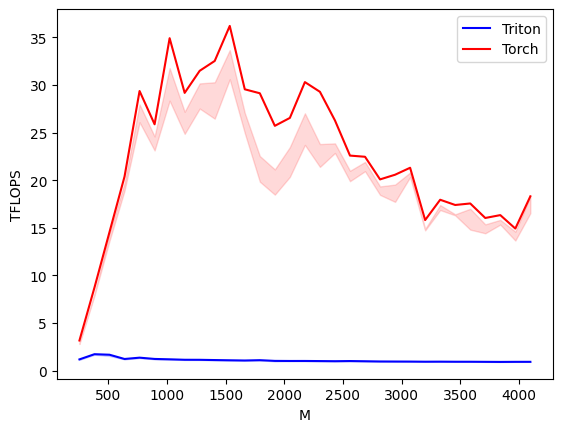

matmul-performance:
         M       N       K    Triton      Torch
0    256.0   256.0   256.0  1.190211   3.172696
1    384.0   384.0   384.0  1.736053   8.738133
2    512.0   512.0   512.0  1.680410  14.563555
3    640.0   640.0   640.0  1.233605  20.388253
4    768.0   768.0   768.0  1.372182  29.368830
5    896.0   896.0   896.0  1.237894  25.874934
6   1024.0  1024.0  1024.0  1.198193  34.916163
7   1152.0  1152.0  1152.0  1.151119  29.172464
8   1280.0  1280.0  1280.0  1.146917  31.492553
9   1408.0  1408.0  1408.0  1.120983  32.526070
10  1536.0  1536.0  1536.0  1.096799  36.204030
11  1664.0  1664.0  1664.0  1.073894  29.549135
12  1792.0  1792.0  1792.0  1.108445  29.134190
13  1920.0  1920.0  1920.0  1.032979  25.713987
14  2048.0  2048.0  2048.0  1.024299  26.545047
15  2176.0  2176.0  2176.0  1.025714  30.306271
16  2304.0  2304.0  2304.0  1.014170  29.286578
17  2432.0  2432.0  2432.0  1.001048  26.279072
18  2560.0  2560.0  2560.0  1.016916  22.589031
19  2688.0  2688.0  

In [9]:
benchmark.run(print_data=True, show_plots=True)